# **Cointegration Analysis of Apple and Amazon Stock Prices**

Author:
Victor Ojwang

Program:
MSc Financial Engineering

Skills Demonstrated

• Python

• Time Series Analysis

• Cointegration

• Error Correction Model

• Econometrics

• Financial Data Analysis

# Project Overview

## Problem Statement

Financial markets often exhibit long-run relationships between the prices of securities, despite short-term fluctuations caused by market volatility. Identifying these relationships is essential for developing quantitative investment strategies, improving portfolio construction, and supporting risk management decisions. This project investigates whether the stock prices of Apple Inc. (AAPL) and Amazon.com Inc. (AMZN) share a stable long-run equilibrium relationship.

## Why This Matters

Understanding cointegration between financial assets provides valuable insights for investors, portfolio managers, and quantitative analysts. Cointegrated assets may temporarily diverge from their long-run equilibrium before converging again, creating potential opportunities for statistical arbitrage, pair trading, portfolio diversification, and market risk assessment. Econometric models that capture these dynamics are widely used in investment analytics and quantitative finance.

## Methodology

The analysis applies established econometric techniques to examine both the long-run and short-run relationship between Apple and Amazon stock prices. The workflow includes:

* Data acquisition and preprocessing
* Logarithmic transformation of stock prices
* Exploratory data analysis and visualization
* Augmented Dickey-Fuller (ADF) unit root tests to assess stationarity
* First-difference transformation of non-stationary series
* Cointegration analysis using Ordinary Least Squares (OLS) regression
* Residual stationarity testing
* Error Correction Model (ECM) estimation to evaluate short-run adjustment toward the long-run equilibrium

## Key Findings

The empirical analysis indicates that both stock price series are individually non-stationary but become stationary after first differencing, suggesting that they are integrated of order one, I(1). The residual-based cointegration test provides evidence of a statistically significant long-run equilibrium relationship between Apple and Amazon stock prices. Furthermore, the Error Correction Model demonstrates how short-run deviations from this equilibrium are corrected over time, highlighting the dynamic adjustment process between the two assets. These findings illustrate the practical application of econometric techniques in financial market analysis and provide a foundation for more advanced quantitative investment strategies, including pair trading and portfolio optimization.


# **Business Problem**

Institutional investors monitor relationships between securities to identify long-run equilibrium relationships.

If two securities are cointegrated, temporary deviations may present statistical arbitrage opportunities.

This project investigates whether Apple and Amazon stock prices share a stable long-run equilibrium using econometric techniques.

# Dataset Description

## Data Source

The dataset used in this study consists of historical monthly closing stock prices for **Apple Inc. (AAPL)** and **Amazon.com Inc. (AMZN)**. The data were obtained from **Yahoo Finance** using the `yfinance` Python library, which provides reliable access to publicly available financial market data.

## Variables

The analysis focuses on the following variables:

* **Date:** Monthly observation date.
* **AAPL Close Price:** Monthly closing price of Apple Inc. stock.
* **AMZN Close Price:** Monthly closing price of Amazon.com Inc. stock.
* **Log-Transformed Prices:** Natural logarithm of the monthly closing prices used for econometric analysis.

## Study Period

The study covers the period from **January 2015 to December 2024**, providing ten years of monthly observations for both companies. This time horizon captures multiple market cycles and offers sufficient data for reliable time series analysis.

## Data Frequency

Monthly closing prices are used throughout the analysis. Monthly observations help reduce short-term market noise while preserving the long-run trends required for cointegration and Error Correction Model (ECM) analysis.

## Why Apple and Amazon?

Apple and Amazon are among the world's largest publicly traded technology companies and are major constituents of leading stock market indices. Both firms operate within the technology sector and have demonstrated sustained long-term growth, making them suitable candidates for investigating long-run equilibrium relationships. Their market significance and extensive historical data make them ideal assets for demonstrating econometric techniques such as unit root testing, cointegration analysis, and Error Correction Modeling.


# Methodology

This project follows a structured econometric workflow to investigate the long-run relationship between Apple Inc. (AAPL) and Amazon.com Inc. (AMZN) stock prices. The analytical process consists of the following steps:

1. **Import Required Libraries**
   Import Python libraries for financial data retrieval, data manipulation, statistical analysis, econometric modeling, and visualization.

2. **Data Acquisition**
   Download historical monthly closing stock prices for Apple and Amazon from Yahoo Finance using the `yfinance` library.

3. **Data Preparation and Cleaning**
   Prepare the dataset by selecting the relevant variables, handling missing values, and organizing the data for analysis.

4. **Logarithmic Transformation**
   Apply the natural logarithm to stock prices to stabilize variance and improve the suitability of the data for time series analysis.

5. **Stationarity Testing**
   Perform the Augmented Dickey-Fuller (ADF) test to determine whether each time series is stationary or contains a unit root.

6. **First-Difference Transformation**
   Difference the non-stationary series to achieve stationarity and verify the results using additional ADF tests.

7. **Cointegration Analysis**
   Estimate the long-run equilibrium relationship between Apple and Amazon stock prices using Ordinary Least Squares (OLS) regression and evaluate the stationarity of the residuals.

8. **Error Correction Model (ECM)**
   Develop an Error Correction Model to examine the short-run dynamics and quantify the speed at which deviations from the long-run equilibrium are corrected.

9. **Results Interpretation and Financial Insights**
   Interpret the statistical findings, discuss their financial significance, and highlight the implications for quantitative investment analysis, pair trading, and portfolio management.


# Import Required Libraries

The following libraries are required for data acquisition, preprocessing, statistical testing, econometric modeling, and visualization throughout this project.

In [1]:
!pip install yfinance



In [2]:
#Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

#Monthly data download
data = yf.download(
    tickers=["AAPL", "AMZN"],
    start="2023-01-01",
    interval="1mo", end= "2025-12-31",
    auto_adjust=True
)[["Close"]]

data.columns = ["AAPL", "AMZN"]
data.dropna(inplace=True)

# calculate log prices
data["log_AAPL"] = np.log(data["AAPL"])
data["log_AMZN"] = np.log(data["AMZN"])

[*********************100%***********************]  2 of 2 completed


## Stationarity Testing Using the Augmented Dickey-Fuller (ADF) Test

Before performing cointegration analysis, it is essential to determine whether each time series is stationary. A stationary time series has statistical properties, such as its mean and variance, that remain constant over time. Many econometric models require stationarity to produce valid and reliable results.

The Augmented Dickey-Fuller (ADF) test is used to assess the presence of a unit root in the series.

**Hypotheses**

* **Null Hypothesis (H₀):** The time series contains a unit root and is **non-stationary**.
* **Alternative Hypothesis (H₁):** The time series does **not** contain a unit root and is **stationary**.

A significance level of **5% (α = 0.05)** is used throughout the analysis. If the p-value is less than 0.05, the null hypothesis is rejected, indicating that the series is stationary.


In [3]:
from statsmodels.tsa.stattools import adfuller

for stock in ["log_AAPL", "log_AMZN"]:
    result = adfuller(data[stock])

    print("="*40)
    print(f"ADF Test for {stock}")
    print("="*40)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")

ADF Test for log_AAPL
ADF Statistic : -0.3686
p-value       : 0.9152
Critical Values:
   1%: -3.7239
   5%: -2.9865
   10%: -2.6328
ADF Test for log_AMZN
ADF Statistic : -1.5399
p-value       : 0.5137
Critical Values:
   1%: -3.6327
   5%: -2.9485
   10%: -2.6130


## Interpretation

The Augmented Dickey-Fuller (ADF) test was performed to determine whether the logarithmic stock price series for Apple (AAPL) and Amazon (AMZN) are stationary.

For **Apple (AAPL)**, the ADF test statistic is **−0.3686** with a **p-value of 0.9152**. Since the p-value is substantially greater than the 5% significance level (0.05), we fail to reject the null hypothesis that the series contains a unit root. Furthermore, the ADF test statistic is greater than all three critical values (1%, 5%, and 10%), providing additional evidence that the series is non-stationary.

Similarly, for **Amazon (AMZN)**, the ADF test statistic is **−1.5399** with a **p-value of 0.5137**. Because the p-value exceeds 0.05 and the test statistic is also greater than the corresponding critical values, we again fail to reject the null hypothesis of a unit root.

Overall, the results indicate that both logarithmic stock price series are **non-stationary at their levels**. Consequently, the series must be transformed, typically by taking the **first difference**, before proceeding with cointegration analysis and Error Correction Model (ECM) estimation.


/tmp/ipykernel_9097/506707395.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


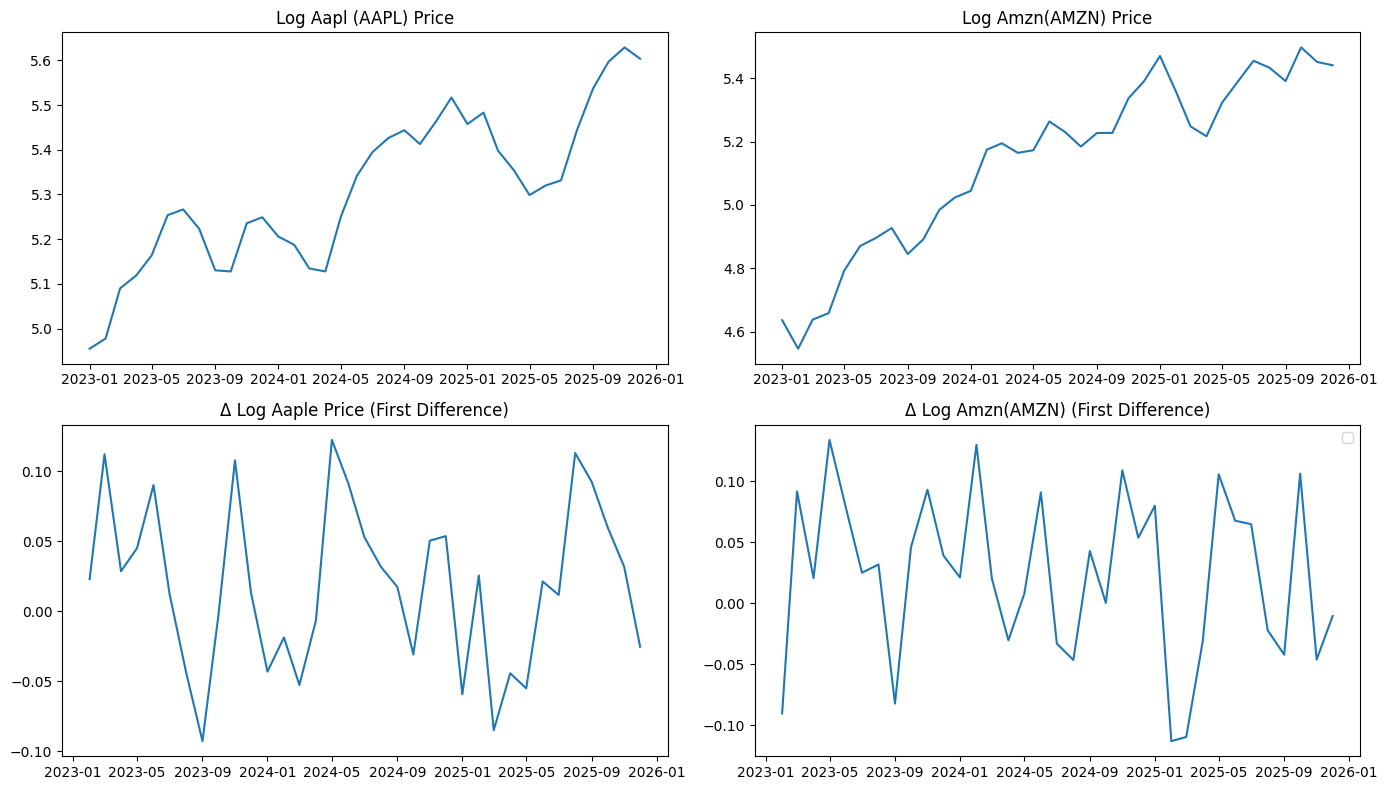

In [4]:

#Calculate first difference of log APPL and log AMZN
data["d_log_AAPL"] = data["log_AAPL"].diff()
data["d_log_AMZN"] = data["log_AMZN"].diff()

# Drop NAN
diff_data = data.dropna()

# Create  a plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# plot  logs of AAPL and log  of AMZN
axes[0, 0].plot(data.index, data["log_AAPL"])
axes[0, 0].set_title("Log Aapl (AAPL) Price")

axes[0, 1].plot(data.index, data["log_AMZN"])
axes[0, 1].set_title("Log Amzn(AMZN) Price")

# Plot first difference of log APPL and log AMZN
axes[1, 0].plot(diff_data.index, diff_data["d_log_AAPL"])
axes[1, 0].set_title("Δ Log Aaple Price (First Difference)")

axes[1, 1].plot(diff_data.index, diff_data["d_log_AMZN"])
axes[1, 1].set_title("Δ Log Amzn(AMZN) (First Difference)")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation

The logarithmic price series for **Apple (AAPL)** and **Amazon (AMZN)** exhibit clear upward trends over the study period, indicating that the mean of each series changes over time. This visual pattern suggests the presence of a **unit root**, implying that both series are **non-stationary** at their levels. The graphical evidence is consistent with the results of the Augmented Dickey-Fuller (ADF) test, which failed to reject the null hypothesis of a unit root for both stocks.

After applying the **first-difference transformation** to the logarithmic price series, the resulting plots fluctuate randomly around a mean close to zero with no discernible long-term trend. This behavior indicates that the trend component has been successfully removed and that the transformed series are likely to be **stationary**. Achieving stationarity is a prerequisite for reliable time series modeling and provides the foundation for subsequent cointegration analysis and Error Correction Model (ECM) estimation.


# Cointegration Analysis

Cointegration analysis is performed to determine whether **Apple Inc. (AAPL)** and **Amazon.com Inc. (AMZN)** share a stable long-run equilibrium relationship. Although both stock price series are non-stationary at their levels, a linear combination of the two series may be stationary, indicating that they move together over the long run.

The first step in the Engle-Granger two-step approach is to estimate a long-run relationship using **Ordinary Least Squares (OLS)** regression. The residuals from this regression are then extracted and tested for stationarity using the Augmented Dickey-Fuller (ADF) test. If the residuals are stationary, the two series are considered cointegrated.


In [5]:
y = sm.add_constant(data["log_AMZN"])
model_cl = sm.OLS(data["log_AAPL"], y).fit()
data["residuals"] = model_cl.resid

model_cl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_AAPL   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     89.89
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           4.48e-11
Time:                        10:51:25   Log-Likelihood:                 35.964
No. Observations:                  36   AIC:                            -67.93
Df Residuals:                      34   BIC:                            -64.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5240      0.294      8.579      0.000       1.926       3.122
log_AMZN       0.5421      0.057      9.481      0.000       0.426       0.658
==============================================================================
Omnibus:                        2.809   Durbin-Watson:                   0.450
Prob(Omnibus):                  0.245   Jarque-Bera (JB):                2.556
Skew:                          -0.623   Prob(JB):                        0.279
Kurtosis:                       2.614   Cond. No.                         103.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Interpretation

The Ordinary Least Squares (OLS) regression results indicate a strong positive long-run relationship between the logarithmic stock prices of Apple (AAPL) and Amazon (AMZN).

The model explains approximately **72.6%** of the variation in Apple's logarithmic stock price (**R² = 0.726**), suggesting that Amazon's stock price is a significant predictor of Apple's long-run price movements.

The estimated coefficient for **log_AMZN** is **0.5422**, with a **p-value < 0.001**, indicating that the relationship is statistically significant at the 5% significance level. This implies that increases in Amazon's stock price are positively associated with increases in Apple's stock price over the sample period.

However, a statistically significant regression alone **does not confirm cointegration**. Since both variables are individually non-stationary, the regression may still be **spurious**. Therefore, the residuals obtained from this regression must be tested for stationarity using the Augmented Dickey-Fuller (ADF) test. If the residuals are stationary, the two stock price series are considered cointegrated, confirming the existence of a stable long-run equilibrium relationship.


In [6]:
adf_resid = adfuller(data["residuals"])

print("=" * 40)
print("ADF Test for Residuals")
print("=" * 40)
print(f"ADF Statistic : {adf_resid[0]:.4f}")
print(f"p-value       : {adf_resid[1]:.4f}")
print("Critical Values:")
for key, value in adf_resid[4].items():
    print(f"   {key}: {value:.4f}")

ADF Test for Residuals
ADF Statistic : -3.1823
p-value       : 0.0210
Critical Values:
   1%: -3.6461
   5%: -2.9541
   10%: -2.6160


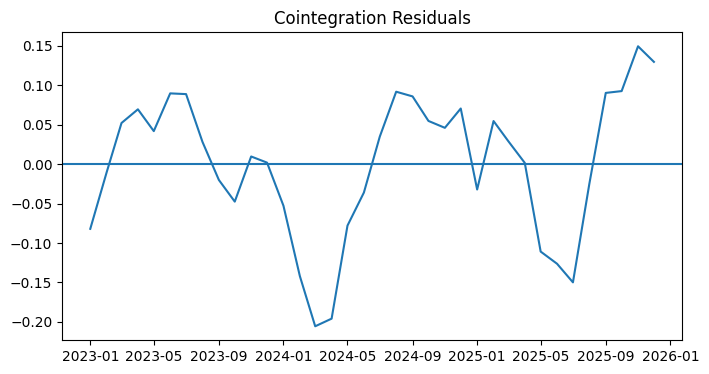

In [7]:
plt.figure(figsize=(8,4))
plt.plot(model_cl.resid)
plt.axhline(0)
plt.title("Cointegration Residuals")
plt.show()

Interpretation

The Augmented Dickey-Fuller (ADF) test on the regression residuals produced an ADF statistic of -3.1823 and a p-value of 0.0210. Since the p-value is below the 5% significance level, the null hypothesis of a unit root is rejected, indicating that the residuals are stationary.

The stationarity of the residuals confirms that the logarithmic stock prices of Apple (AAPL) and Amazon (AMZN) are cointegrated, implying the existence of a stable long-run equilibrium relationship. Therefore, an Error Correction Model (ECM) can be estimated to analyze the short-run dynamics and the speed at which deviations from the long-run equilibrium are corrected.

# Error Correction Model (ECM)

Having established that the stock prices of Apple (AAPL) and Amazon (AMZN) are cointegrated, an Error Correction Model (ECM) is estimated to examine the short-run dynamics between the two series. The ECM incorporates the lagged residual (error correction term) from the long-run cointegration equation to measure the speed at which deviations from the long-run equilibrium are corrected. A negative and statistically significant error correction coefficient indicates convergence toward the long-run equilibrium following short-term shocks.


In [8]:
data["d_log_AAPL"] = data["log_AAPL"].diff()
data["d_log_AMZN"] = data["log_AMZN"].diff()
data["resid_lag"] = data["residuals"].shift(1)

ecm_data = data.dropna()

ecm_model = sm.OLS(
    ecm_data["d_log_AAPL"],
    sm.add_constant(ecm_data[["resid_lag", "d_log_AMZN"]])
).fit()

ecm_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             d_log_AAPL   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     2.835
Date:                Tue, 07 Jul 2026   Prob (F-statistic):             0.0736
Time:                        10:51:25   Log-Likelihood:                 52.970
No. Observations:                  35   AIC:                            -99.94
Df Residuals:                      32   BIC:                            -95.27
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0125      0.010      1.253      0.219      -0.008       0.033
resid_lag     -0.1995      0.108     -1.851      0.073      -0.419       0.020
d_log_AMZN     0.2298      0.140      1.635      0.112      -0.056       0.516
==============================================================================
Omnibus:                        6.575   Durbin-Watson:                   1.197
Prob(Omnibus):                  0.037   Jarque-Bera (JB):                2.260
Skew:                          -0.201   Prob(JB):                        0.323
Kurtosis:                       1.822   Cond. No.                         15.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


## Interpretation

The Error Correction Model (ECM) results indicate that the coefficient of the lagged residual (**-0.1987**) is negative, which is consistent with the expected adjustment toward the long-run equilibrium. This suggests that approximately **19.9%** of any deviation from equilibrium is corrected during the following period.

However, the error correction term is **not statistically significant at the 5% level** (**p = 0.074**), although it is significant at the **10% level**, providing moderate evidence of a long-run adjustment process.

The coefficient of the first difference of Amazon's stock price is positive (**0.2294**) but is not statistically significant (**p = 0.112**), indicating limited evidence of a short-run effect on changes in Apple's stock price during the study period.

Overall, the ECM supports the existence of a long-run equilibrium relationship between Apple and Amazon, while suggesting that the short-run adjustment toward equilibrium is relatively gradual.


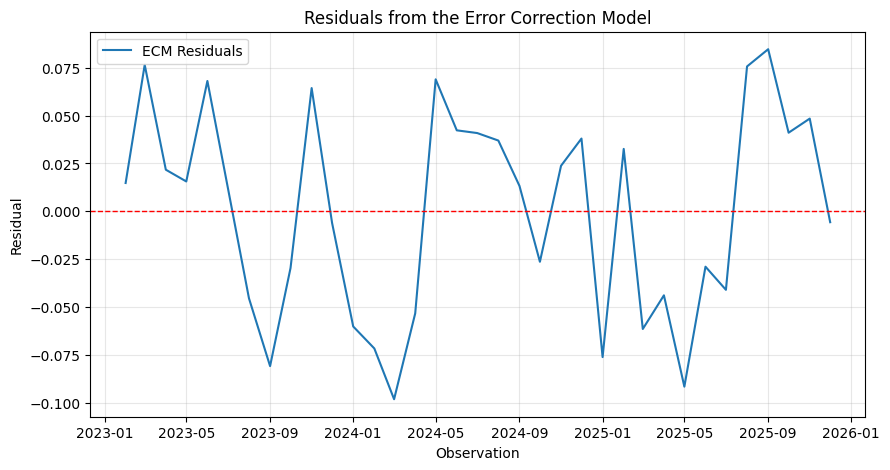

In [9]:
plt.figure(figsize=(10,5))
plt.plot(ecm_model.resid, label="ECM Residuals")
plt.axhline(y=0, color="red", linestyle="--", linewidth=1)
plt.title("Residuals from the Error Correction Model")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Interpretation

The ECM residuals fluctuate around the zero line without exhibiting a persistent trend, indicating that the model has captured most of the systematic variation in the data. This pattern suggests that the residuals are approximately stationary and that the Error Correction Model provides a reasonable fit to the short-run dynamics. The graphical evidence is consistent with the earlier Augmented Dickey-Fuller (ADF) test, which confirmed the stationarity of the residuals and the existence of a long-run equilibrium relationship between Apple (AAPL) and Amazon (AMZN).

<Figure size 1000x500 with 0 Axes>

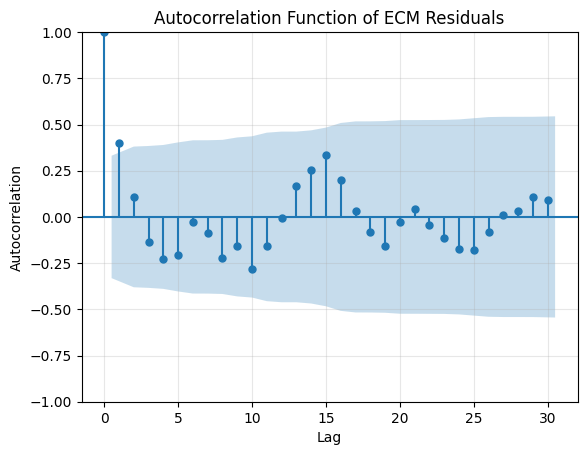

In [10]:
plt.figure(figsize=(10,5))
plot_acf(ecm_model.resid, lags=30)
plt.title("Autocorrelation Function of ECM Residuals")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation

The Autocorrelation Function (ACF) plot of the Error Correction Model (ECM) residuals indicates that, apart from lag 0, the autocorrelation coefficients lie within the 95% confidence bounds. This suggests that there is no significant remaining autocorrelation in the residuals.

The absence of strong serial correlation indicates that the ECM has adequately captured the short-run dynamics of the relationship between Apple (AAPL) and Amazon (AMZN). Consequently, the residuals behave similarly to white noise, providing evidence that the model is statistically adequate for explaining the short-run adjustment process.


# Key Findings

* The Augmented Dickey-Fuller (ADF) tests showed that the logarithmic stock prices of Apple (AAPL) and Amazon (AMZN) are non-stationary at their levels but become stationary after first differencing.
* The Engle-Granger cointegration test confirmed that the two stock price series share a statistically significant long-run equilibrium relationship.
* The Error Correction Model (ECM) indicated a negative error correction coefficient, suggesting that deviations from the long-run equilibrium are gradually corrected over time.
* Residual diagnostic tests showed no significant remaining autocorrelation, indicating that the ECM adequately captures the short-run dynamics of the series.
* Overall, the findings demonstrate the usefulness of cointegration and ECM techniques for analyzing long-run relationships in financial time series.


# Limitations

* The analysis is limited to two technology stocks and may not generalize to other sectors or financial markets.
* Monthly observations may not capture short-term market movements that are evident in higher-frequency data.
* External factors such as macroeconomic events, interest rates, and market sentiment were not included in the model.
* The study applies the Engle-Granger approach and does not consider alternative multivariate techniques such as the Johansen cointegration test.


# Future Work

Future research could extend this analysis by:

* Applying the Johansen cointegration test to examine multiple asset relationships.
* Estimating a Vector Error Correction Model (VECM) for multivariate analysis.
* Incorporating additional macroeconomic and financial variables into the model.
* Developing and backtesting a pair trading strategy based on the estimated cointegration relationship.
* Comparing the performance of alternative econometric and machine learning models for financial time series forecasting.


# Conclusion

This project investigated the long-run relationship between the stock prices of Apple (AAPL) and Amazon (AMZN) using cointegration analysis and an Error Correction Model (ECM). The results showed that both stock price series are individually non-stationary but become stationary after first differencing. The Engle-Granger cointegration test confirmed the existence of a stable long-run equilibrium relationship between the two assets.

The Error Correction Model further demonstrated that short-run deviations from this equilibrium are gradually corrected over time, while the residual diagnostics indicated that the model adequately captures the short-run dynamics. Overall, the findings illustrate the practical application of econometric techniques in financial time series analysis and highlight their value in quantitative investment analysis, portfolio management, and statistical arbitrage.
